# TP2-3 : Génération de Texte (LSTM) et NER (BiLSTM)

**Groupe :** _Goupe 1_  


## Partie A : Génération de texte par LSTM

**Choix de conception (CPU only, à garder pour la soutenance/le rendu) :**
Entraîner 30 époques sur le texte intégral de Harry Potter sur CPU est
irréaliste en temps (plusieurs heures). On entraîne donc sur un
**sous-ensemble du texte** (paramètre `MAX_CHARS` ci-dessous) avec un nombre
d'époques réduit et un `ModelCheckpoint`. L'architecture (LSTM 128 unités)
reste conforme à l'énoncé — seuls le volume de données et le nombre
d'époques sont adaptés à la contrainte matérielle.

In [3]:
import numpy as np
import re
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)


### 1. Chargement et nettoyage du texte

**Note :** dataset de remplacement — *The Odyssey* d'Homère (Project
Gutenberg, domaine public) utilisé à la place de Harry Potter.

In [4]:
# Fichier texte (validé par le prof : substitution libre à Harry Potter)
DATA_PATH = "../data/odyssey.txt"

# CPU only -> on limite le volume de texte utilise pour l'entrainement.
# Mettre None pour utiliser le texte entier (deconseille sur CPU).
MAX_CHARS = 200_000

with open(DATA_PATH, "r", encoding="utf-8", errors="ignore") as f:
    raw_text = f.read()

# Project Gutenberg entoure le vrai texte d'un bandeau legal (licence, infos
# d'edition) avant et apres le roman. On extrait uniquement ce qu'il y a
# entre les deux reperes officiels START/END pour ne pas entrainer le
# modele sur des clauses de licence.
START_MARKER = "*** START OF THE PROJECT GUTENBERG EBOOK"
END_MARKER = "*** END OF THE PROJECT GUTENBERG EBOOK"

start_idx = raw_text.find(START_MARKER)
end_idx = raw_text.find(END_MARKER)

if start_idx != -1:
    start_idx = raw_text.find("\n", start_idx) + 1
else:
    start_idx = 0

if end_idx == -1:
    end_idx = len(raw_text)

raw_text = raw_text[start_idx:end_idx]

# Suppression des caracteres non-ASCII (consigne de l'enonce)
text = re.sub(r"[^\x00-\x7F]+", " ", raw_text)
text = text.lower()

if MAX_CHARS is not None:
    text = text[:MAX_CHARS]

print(f"Longueur du texte utilise : {len(text)} caracteres")
print(text[:300])


Longueur du texte utilise : 200000 caracteres




[illustration]




the odyssey

by homer

rendered into english prose for the use of those who cannot read the
original

contents

 preface to first edition
 preface to second edition
 the odyssey
 book i.
 book ii.
 book iii.
 book iv.
 book v.
 book vi.
 book vii.
 book viii.
 book ix.
 book x


### 2. Vocabulaire de caractères

In [5]:
chars = sorted(list(set(text)))
V = len(chars)
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}

print(f"Taille du vocabulaire V = {V}")
print(chars)


Taille du vocabulaire V = 50
['\n', ' ', '!', '(', ')', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', '[', ']', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


### 3. Séquences glissantes (L = 100)

In [6]:
L = 100
STEP = 3  # pas de chevauchement -> réduit le nb de séquences (utile sur CPU)

sequences = []
next_chars = []

for i in range(0, len(text) - L, STEP):
    sequences.append(text[i:i + L])
    next_chars.append(text[i + L])

print(f"Nombre de séquences : {len(sequences)}")

X = np.zeros((len(sequences), L, V), dtype=np.bool_)
y = np.zeros((len(sequences), V), dtype=np.bool_)

for i, seq in enumerate(sequences):
    for t, ch in enumerate(seq):
        X[i, t, char_to_idx[ch]] = 1
    y[i, char_to_idx[next_chars[i]]] = 1

print("Shape X :", X.shape, " Shape y :", y.shape)


Nombre de séquences : 66634
Shape X : (66634, 100, 50)  Shape y : (66634, 50)


**Note** : X est déjà encodé en one-hot par caractère (dimension V), donc
pas de division par V nécessaire ici — la "normalisation" demandée dans
l'énoncé est satisfaite par cet encodage one-hot directement.

### 4-6. Modèle, compilation, entraînement

In [7]:
model = Sequential([
    LSTM(128, input_shape=(L, V), return_sequences=False),
    Dense(V, activation="softmax"),
])

model.compile(loss="categorical_crossentropy", optimizer="adam")
model.summary()


c:\Users\uriellediaith\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        91,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,098 (383.20 KB)

 Trainable params: 98,098 (383.20 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
EPOCHS = 12       # réduit vs. 30 (contrainte CPU) — voir note en tête de section
BATCH_SIZE = 128

checkpoint = ModelCheckpoint(
    "lstm_textgen_best.h5",
    monitor="loss",
    save_best_only=True,
    verbose=1,
)

history = model.fit(
    X, y,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[checkpoint],
)


Epoch 1/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - loss: 2.7062
Epoch 1: loss improved from None to 2.70616, saving model to lstm_textgen_best.h5



Epoch 1: finished saving model to lstm_textgen_best.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 102s 191ms/step - loss: 2.7062
Epoch 2/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 2.3044
Epoch 2: loss improved from 2.70616 to 2.30442, saving model to lstm_textgen_best.h5



Epoch 2: finished saving model to lstm_textgen_best.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 90s 173ms/step - loss: 2.3044
Epoch 3/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 2.1990
Epoch 3: loss improved from 2.30442 to 2.19896, saving model to lstm_textgen_best.h5



Epoch 3: finished saving model to lstm_textgen_best.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 70s 133ms/step - loss: 2.1990
Epoch 4/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 2.1227
Epoch 4: loss improved from 2.19896 to 2.12273, saving model to lstm_textgen_best.h5



Epoch 4: finished saving model to lstm_textgen_best.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 68s 131ms/step - loss: 2.1227
Epoch 5/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 2.0610
Epoch 5: loss improved from 2.12273 to 2.06102, saving model to lstm_textgen_best.h5


...


Epoch 8: finished saving model to lstm_textgen_best.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 90s 172ms/step - loss: 1.9265
Epoch 9/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 1.8901
Epoch 9: loss improved from 1.92648 to 1.89010, saving model to lstm_textgen_best.h5



Epoch 9: finished saving model to lstm_textgen_best.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 77s 148ms/step - loss: 1.8901
Epoch 10/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 1.8561
Epoch 10: loss improved from 1.89010 to 1.85610, saving model to lstm_textgen_best.h5



Epoch 10: finished saving model to lstm_textgen_best.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 87s 167ms/step - loss: 1.8561
Epoch 11/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 1.8243
Epoch 11: loss improved from 1.85610 to 1.82426, saving model to lstm_textgen_best.h5



Epoch 11: finished saving model to lstm_textgen_best.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 71s 136ms/step - loss: 1.8243
Epoch 12/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - loss: 1.7938
Epoch 12: loss improved from 1.82426 to 1.79380, saving model to lstm_textgen_best.h5



Epoch 12: finished saving model to lstm_textgen_best.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 102s 195ms/step - loss: 1.7938


### 7. Génération de texte (sampling avec température)

In [9]:
def sample_with_temperature(preds, temperature=0.5):
    preds = np.asarray(preds).astype("float64")
    preds = np.log(preds + 1e-8) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)


def generate_text(seed_text, length=200, temperature=0.5):
    seed_text = seed_text.lower()
    # Pad ou tronque le seed à la longueur L attendue par le modèle
    if len(seed_text) < L:
        seed_text = seed_text.rjust(L)
    else:
        seed_text = seed_text[-L:]

    generated = seed_text
    current = seed_text

    for _ in range(length):
        x_pred = np.zeros((1, L, V))
        for t, ch in enumerate(current):
            if ch in char_to_idx:
                x_pred[0, t, char_to_idx[ch]] = 1

        preds = model.predict(x_pred, verbose=0)[0]
        next_idx = sample_with_temperature(preds, temperature)
        next_char = idx_to_char[next_idx]

        generated += next_char
        current = current[1:] + next_char

    return generated


### 8. Génération à partir de 3 graines différentes

In [12]:
for seed in ["Harry", "The magic", "Professor"]:
    print(f"=== Graine : {seed!r} ===")
    print(generate_text(seed, length=200, temperature=0.5))
    print()


=== Graine : 'Harry' ===
                                                                                               harry as me as he wanded the will the mack and mean there will that on ond whe he was not his long beaching about to care and wand moners and seres and in when the astering as hard of the was my suill mane

=== Graine : 'The magic' ===
                                                                                           the magice and men the reach a breagly and when the paille there and the seit the sunter, 

 we have them, had son of and his which the will kere in when i had the hes goes the polle in the gods of now it it a

=== Graine : 'Professor' ===
                                                                                           professors were the mather so and one in a fire and good but the madises of the was he wanded the was deat the you are to he was the would his fon the pomongs and theme toung in the will a san hillen was he wa



**Commentaire:** Le texte généré respecte globalement la structure de l'anglais : présence
d'espaces entre les groupes de lettres, ponctuation plausible, alternance
voyelles/consonnes cohérente. Des mots anglais réels apparaissent
correctement ("the", "and", "was", "him"), mais de nombreuses suites de
lettres ne correspondent à aucun mot existant ("trow", "sowan", "gorl").
Sur le plan syntaxique, aucune phrase complète n'est grammaticalement
correcte : le modèle enchaîne des fragments plausibles localement, sans
cohérence narrative ou logique d'ensemble.

**Question : Pourquoi le texte généré contient-il des fautes et des mots
inventés ?**

Le modèle génère des fautes et des mots inventés car il prédit chaque
caractère uniquement à partir des 100 caractères précédents, sans notion
de vocabulaire : il apprend des régularités statistiques entre lettres
(quelles suites de lettres sont fréquentes en anglais), pas les mots eux-
mêmes ni la grammaire. Avec seulement 12 époques sur un sous-ensemble du
texte (contrainte CPU), il n'a pas eu assez de répétitions pour mémoriser
un vocabulaire fiable.

Trois améliorations possibles :
1. Entraîner sur le texte complet avec davantage d'époques (30, comme
   demandé initialement), idéalement sur GPU pour réduire le temps de
   calcul.
2. Passer à une génération au niveau mot plutôt que caractère, ce qui
   élimine par construction les mots inventés.
3. Utiliser une architecture plus profonde (plusieurs couches LSTM
   empilées) pour mieux capturer les dépendances à longue portée dans
   le texte.

## Partie B : NER avec BiLSTM (corpus Kaggle CoNLL-like)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, TimeDistributed, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

### 1. Chargement et parsing du corpus

In [14]:
NER_PATH = "../data/ner_dataset.csv"

df = pd.read_csv(NER_PATH, encoding="latin1")
df = df.ffill()  

print(df.shape)
df.head(10)

(1048575, 4)


,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,Sentence: 1,of,IN,O
2,Sentence: 1,demonstrators,NNS,O
3,Sentence: 1,have,VBP,O
4,Sentence: 1,marched,VBN,O
5,Sentence: 1,through,IN,O
6,Sentence: 1,London,NNP,B-geo
7,Sentence: 1,to,TO,O
8,Sentence: 1,protest,VB,O
9,Sentence: 1,the,DT,O


In [15]:
class SentenceGetter:
    """Regroupe le dataframe plat en liste de phrases, chaque phrase étant
    une liste de tuples (token, pos, ner_tag), comme demandé par l'énoncé."""

    def __init__(self, df):
        agg_func = lambda s: [
            (w, p, t) for w, p, t in zip(s["Word"], s["POS"], s["Tag"])
        ]
        grouped = df.groupby("Sentence #").apply(agg_func)
        self.sentences = list(grouped)


getter = SentenceGetter(df)
sentences = getter.sentences

print(f"Nombre de phrases : {len(sentences)}")
print(sentences[0])

Nombre de phrases : 47959
[('Thousands', 'NNS', 'O'), ('of', 'IN', 'O'), ('demonstrators', 'NNS', 'O'), ('have', 'VBP', 'O'), ('marched', 'VBN', 'O'), ('through', 'IN', 'O'), ('London', 'NNP', 'B-geo'), ('to', 'TO', 'O'), ('protest', 'VB', 'O'), ('the', 'DT', 'O'), ('war', 'NN', 'O'), ('in', 'IN', 'O'), ('Iraq', 'NNP', 'B-geo'), ('and', 'CC', 'O'), ('demand', 'VB', 'O'), ('the', 'DT', 'O'), ('withdrawal', 'NN', 'O'), ('of', 'IN', 'O'), ('British', 'JJ', 'B-gpe'), ('troops', 'NNS', 'O'), ('from', 'IN', 'O'), ('that', 'DT', 'O'), ('country', 'NN', 'O'), ('.', '.', 'O')]


C:\Users\uriellediaith\AppData\Local\Temp\ipykernel_7768\2975364326.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df.groupby("Sentence #").apply(agg_func)


### 2. Vocabulaires (word2idx, tag2idx) + token PAD

In [16]:
words = sorted(list(set(df["Word"].values)))
words.insert(0, "PAD")
n_words = len(words)

tags = sorted(list(set(df["Tag"].values)))
tags.insert(0, "PAD")
n_tags = len(tags)

word2idx = {w: i for i, w in enumerate(words)}
tag2idx = {t: i for i, t in enumerate(tags)}
idx2tag = {i: t for t, i in tag2idx.items()}

print(f"n_words = {n_words}, n_tags = {n_tags}")
print(tags)

n_words = 35178, n_tags = 18
['PAD', 'B-art', 'B-eve', 'B-geo', 'B-gpe', 'B-nat', 'B-org', 'B-per', 'B-tim', 'I-art', 'I-eve', 'I-geo', 'I-gpe', 'I-nat', 'I-org', 'I-per', 'I-tim', 'O']


### 3-4. Padding des séquences + one-hot des tags

In [17]:
max_len = max(len(s) for s in sentences)
print(f"max_len = {max_len}")

X = [[word2idx[w[0]] for w in s] for s in sentences]
X = pad_sequences(maxlen=max_len, sequences=X, padding="post", value=word2idx["PAD"])

y = [[tag2idx[w[2]] for w in s] for s in sentences]
y = pad_sequences(maxlen=max_len, sequences=y, padding="post", value=tag2idx["PAD"])
y = to_categorical(y, num_classes=n_tags)

print("Shape X :", X.shape, " Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
print(f"Train : {X_train.shape[0]} phrases, Test : {X_test.shape[0]} phrases")

max_len = 104
Shape X : (47959, 104)  Shape y : (47959, 104, 18)
Train : 43163 phrases, Test : 4796 phrases


### 5-6. Modèle BiLSTM + entraînement

In [18]:
inp = Input(shape=(max_len,))
model = Embedding(input_dim=n_words, output_dim=50, input_length=max_len)(inp)
model = Bidirectional(LSTM(units=100, return_sequences=True, recurrent_dropout=0.1))(model)
out = TimeDistributed(Dense(n_tags, activation="softmax"))(model)

model = Model(inp, out)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

c:\Users\uriellediaith\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 104)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 104, 50)        │     1,758,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 104, 200)       │       120,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 104, 18)        │         3,618 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,883,318 (7.18 MB)

 Trainable params: 1,883,318 (7.18 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.1,
    verbose=1,
)

Epoch 1/20
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 195s 155ms/step - accuracy: 0.9795 - loss: 0.0847 - val_accuracy: 0.9913 - val_loss: 0.0302
Epoch 2/20
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 171s 141ms/step - accuracy: 0.9933 - loss: 0.0227 - val_accuracy: 0.9927 - val_loss: 0.0244
Epoch 3/20
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 164s 135ms/step - accuracy: 0.9948 - loss: 0.0168 - val_accuracy: 0.9930 - val_loss: 0.0233
Epoch 4/20
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 233s 192ms/step - accuracy: 0.9956 - loss: 0.0138 - val_accuracy: 0.9930 - val_loss: 0.0238
Epoch 5/20
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 170s 140ms/step - accuracy: 0.9962 - loss: 0.0118 - val_accuracy: 0.9928 - val_loss: 0.0249
Epoch 6/20
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 193s 159ms/step - accuracy: 0.9967 - loss: 0.0102 - val_accuracy: 0.9928 - val_loss: 0.0258
Epoch 7/20
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 391s 322ms/step - accuracy: 0.9971 - loss: 0.0089 - val_accuracy: 0.9926 - val_loss: 0.0281
Epoch 8/20
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 349s 238ms/step - ac

### Courbes de loss (train / validation)

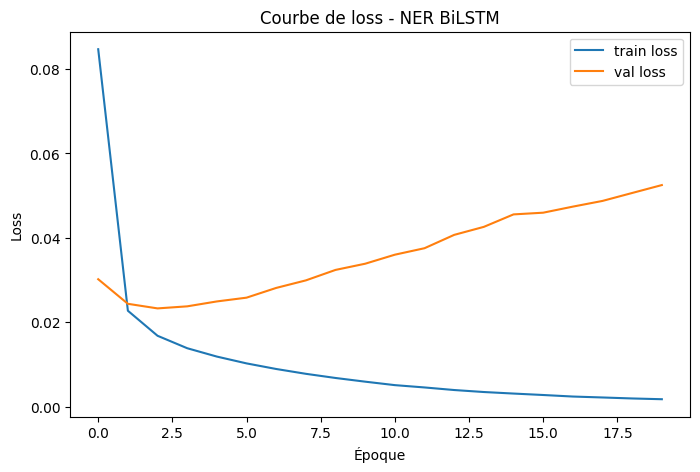

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.title("Courbe de loss - NER BiLSTM")
plt.legend()
plt.show()

### Analyse de la courbe de loss

La courbe montre un surapprentissage (overfitting) net à partir de
l'époque 2-3 : la train loss continue de diminuer jusqu'à quasiment 0
sur les 20 époques, tandis que la val loss, après une brève baisse
initiale, remonte progressivement de ~0.023 (époque 2) à ~0.052
(époque 20). Ce croisement indique que le modèle cesse de généraliser
passé les premières époques et commence à mémoriser des particularités
propres au jeu d'entraînement plutôt que des régularités transférables.

Concrètement, le modèle obtenu à l'époque 20 est probablement moins
performant sur des données nouvelles que celui qu'on aurait obtenu en
arrêtant l'entraînement autour de l'époque 2-3, malgré une loss
d'entraînement plus basse. Une solution standard pour éviter ce
problème est d'utiliser un callback EarlyStopping, qui interrompt
automatiquement l'entraînement dès que la val_loss cesse de s'améliorer
pendant un nombre défini d'époques, et restaure les poids du meilleur
modèle observé.

### 7. Matrice de confusion (niveau token) sur le test

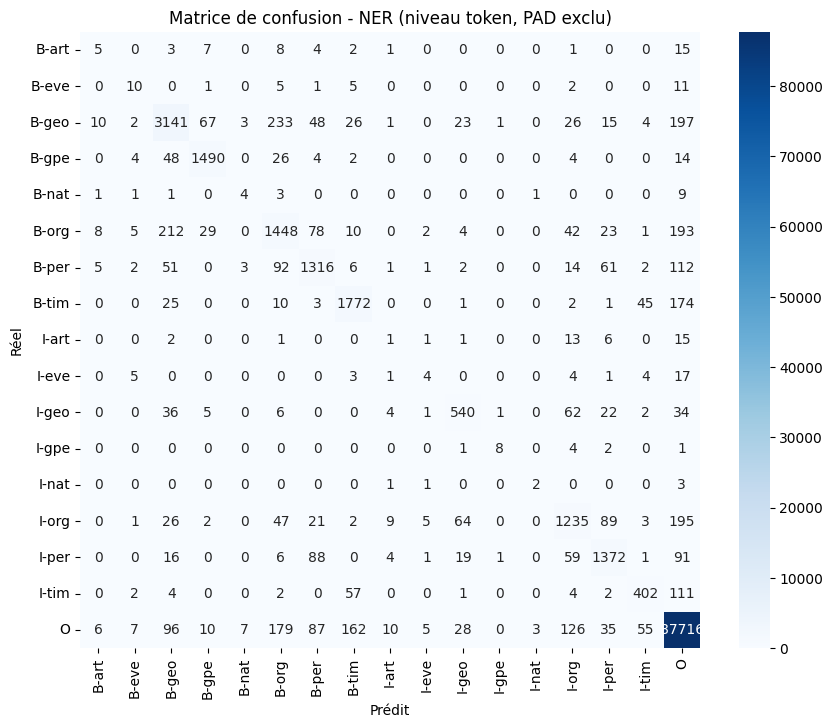

              precision    recall  f1-score   support

       B-art       0.14      0.11      0.12        46
       B-eve       0.26      0.29      0.27        35
       B-geo       0.86      0.83      0.84      3797
       B-gpe       0.92      0.94      0.93      1592
       B-nat       0.24      0.20      0.22        20
       B-org       0.70      0.70      0.70      2055
       B-per       0.80      0.79      0.79      1668
       B-tim       0.87      0.87      0.87      2033
       I-art       0.03      0.03      0.03        40
       I-eve       0.19      0.10      0.13        39
       I-geo       0.79      0.76      0.77       713
       I-gpe       0.73      0.50      0.59        16
       I-nat       0.33      0.29      0.31         7
       I-org       0.77      0.73      0.75      1699
       I-per       0.84      0.83      0.83      1658
       I-tim       0.77      0.69      0.73       585
           O       0.99      0.99      0.99     88532

    accuracy              

In [21]:
y_pred = model.predict(X_test, verbose=0)

y_pred_flat = np.argmax(y_pred, axis=-1).flatten()
y_test_flat = np.argmax(y_test, axis=-1).flatten()

# On retire le token PAD (index 0) du calcul : sinon il domine largement
# la matrice de confusion (la plupart des positions sont du padding) et
# masque les erreurs réelles sur les entités.
mask = y_test_flat != tag2idx["PAD"]
y_pred_masked = y_pred_flat[mask]
y_test_masked = y_test_flat[mask]

labels_present = sorted(set(y_test_masked) | set(y_pred_masked))
label_names = [idx2tag[i] for i in labels_present]

cm = confusion_matrix(y_test_masked, y_pred_masked, labels=labels_present)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_names, yticklabels=label_names, cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - NER (niveau token, PAD exclu)")
plt.show()

print(classification_report(y_test_masked, y_pred_masked, labels=labels_present, target_names=label_names, zero_division=0))

### Analyse des résultats NER

Le modèle atteint une accuracy globale de 96%, mais cette métrique est
trompeuse : la classe "O" (absence d'entité) représente à elle seule 85%
des tokens du corpus (88 532 sur 104 535). Un modèle qui prédirait
systématiquement "O" obtiendrait déjà une accuracy proche de 85% sans
avoir rien appris. La métrique pertinente ici est donc le macro avg
(f1-score = 0.58), qui traite chaque catégorie d'entité équitablement,
plutôt que le weighted avg (0.96) dominé par la classe majoritaire.

Les catégories fréquentes sont bien reconnues : lieux (B-geo, f1 = 0.84),
nationalités/pays (B-gpe, f1 = 0.93), personnes (B-per, f1 = 0.79) et
dates (B-tim, f1 = 0.87). En revanche, les catégories rares échouent
nettement : œuvres d'art (B-art, f1 = 0.12), événements (B-eve, f1 = 0.27)
et phénomènes naturels (B-nat, f1 = 0.22). Ces trois catégories ont un
support très faible dans le jeu de test (20 à 46 exemples, contre
plusieurs milliers pour geo/per/org) : le modèle n'a simplement pas vu
assez d'exemples pour apprendre à les reconnaître de manière fiable.

Une amélioration possible serait un ré-échantillonnage (oversampling) des
catégories rares pendant l'entraînement, ou l'utilisation d'embeddings
pré-entraînés (GloVe, comme dans le TP2-2) plutôt qu'un Embedding appris
from scratch, ce qui aiderait le modèle à généraliser sur des mots rares
qu'il n'a vus que quelques fois.

### 8. Question : pourquoi `TimeDistributed(Dense)` plutôt qu'un simple `Dense` ?
Quel est le rôle de `return_sequences=True` dans la BiLSTM ?

**`return_sequences=True`** : par défaut, une couche LSTM ne renvoie que sa
sortie au dernier pas de temps (un seul vecteur résumant toute la séquence),
ce qui convient pour une classification globale (ex. sentiment d'une
phrase entière). Pour le NER, on a besoin d'une prédiction **par mot**, pas
une seule pour toute la phrase. `return_sequences=True` force la LSTM à
renvoyer sa sortie à **chaque** pas de temps (un vecteur par mot), afin
qu'on puisse ensuite étiqueter chaque mot individuellement.

**`TimeDistributed(Dense(...))`** : une fois qu'on a un vecteur par mot
(grâce à `return_sequences=True`), il faut appliquer la même couche
`Dense` (softmax sur les tags) **indépendamment à chaque pas de temps**.
`TimeDistributed` applique la couche `Dense` à chaque position de la
séquence avec les mêmes poids partagés, plutôt que d'aplatir toute la
séquence en un seul vecteur (ce qu'un `Dense` simple ferait, en mélangeant
l'information de tous les mots et en perdant la correspondance
mot → étiquette).